In [1]:
from pathlib import Path
from dvrptw_bench.data.der_template_builder import template_dict_from_vrptw_instance
from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon

from dvrptw_bench.data.der_solomon_generator import (
    DERTimeWindowGenerator,
    template_from_dict,
    instance_to_dict,
    
)
from dvrptw_bench.data.solomon_parser import parse_solomon
# Create templates for RC family
datasetRoot = Path("../dataset/solomon_rc100")
instances = [parse_solomon(instance, max_customers=4) for instance in find_rc_instances(datasetRoot)]
templates = {
    f"RC1": template_from_dict(template_dict_from_vrptw_instance(instances[0], f"RC1"))
}

In [2]:
from dvrptw_bench.data.der_solomon_generator import Family
from dvrptw_bench.data.rl4co_der_generator import FamilySpec
from dvrptw_bench.rl.interfaces import RLPolicy
from dvrptw_bench.rl.rl4co_policy import RL4COPolicy
from dvrptw_bench.rl.rl_model import build_attention_model


# mean gap=61%
# mean gap = 67% NORMALIZED, 61%
model = build_attention_model(max_epochs=100,
        batch_size=256,
        train_data_size=100_000,
        val_data_size=10_000,
        lr=1e-4,
        normalize_coords=True,
        der_templates=templates,
        family_specs=[FamilySpec("RC1")],
        der_seed=123,
        vehicle_penalty=500,
)
model.train()
policy = RL4COPolicy(model=model)

The capacity capacity for 4 locations is not defined. Using the closest capacity: 20.0                    with 10 locations.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/c

┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ env      │ PenalizedCVRPTWEnv   │      0 │ train │     0 │
│ 1 │ policy   │ AttentionModelPolicy │  694 K │ train │     0 │
│ 2 │ baseline │ WarmupBaseline       │  694 K │ train │     0 │
└───┴──────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.4 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 73                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

Output()

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/ut
ilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

...

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/tr
ainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a 
bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to 
improve performance.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/lo
ops/fit_loop.py:534: Found 69 module(s) in eval mode at the start of training. This may lead to unexpected behavior
during training. If this is intentional, you can ignore this warning.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# Compare RL with OR Tools
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver
or_solutions = []
rl_solutions = []
solver = ORToolsVRPTWSolver()
for instance in instances:
    or_solutions.append(solver.solve(instance, 1))
    rl_solutions.append(policy.infer_instance(instance))


Note: RL reported total_distance differs from recomputed route distance.
Mean RL reported total_distance:   6.08
Mean RL recomputed total_distance: 274.63
Instances compared: 8
Mean OR-Tools cost: 173.15
Mean RL cost:       274.63
Mean gap (RL-OR)%:  60.48%
Median gap%:        53.66%
RL better (<0%):    0
OR better (>0%):    8
Ties (~0%):         0


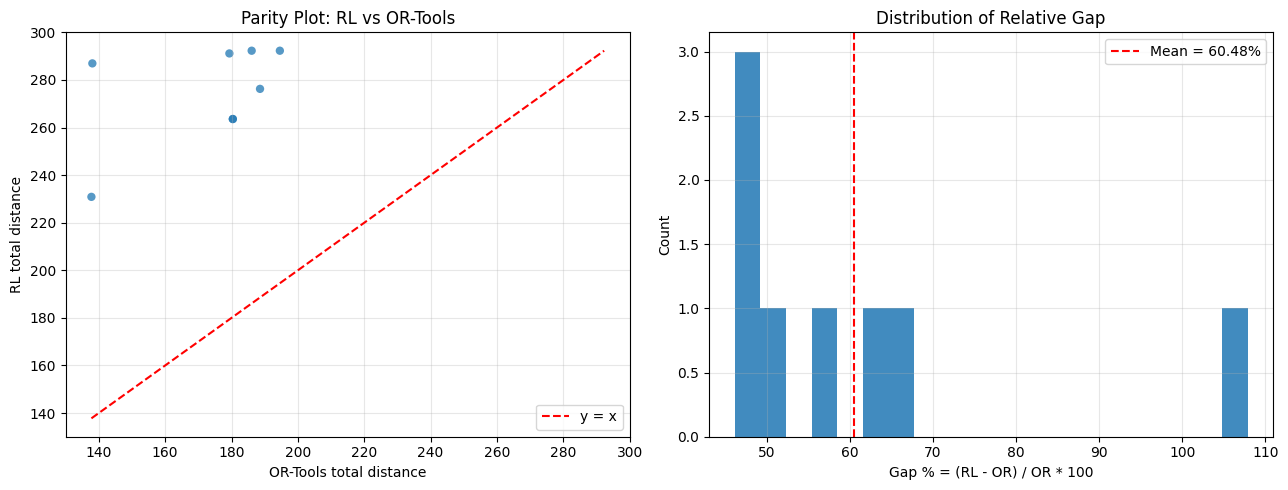

In [ ]:
# Compare OR-Tools vs RL inference results (recomputed objective distance)
import numpy as np
import matplotlib.pyplot as plt
from dvrptw_bench.metrics.objective import total_distance

def _safe_reported_cost(solution_or_cost):
    return float(getattr(solution_or_cost, "total_distance", solution_or_cost))

assert len(instances) == len(or_solutions) == len(rl_solutions), (
    "instances, or_solutions, and rl_solutions must have the same length."
)

# Recompute objective distance from routes for a fair comparison.
ort_costs = np.array([total_distance(inst, sol) for inst, sol in zip(instances, or_solutions)], dtype=float)
rl_costs = np.array([total_distance(inst, sol) for inst, sol in zip(instances, rl_solutions)], dtype=float)

# Optional diagnostics for reported RL values vs recomputed objective values.
rl_reported = np.array([_safe_reported_cost(sol) for sol in rl_solutions], dtype=float)
if not np.allclose(rl_reported, rl_costs, rtol=1e-5, atol=1e-5):
    print("Note: RL reported total_distance differs from recomputed route distance.")
    print(f"Mean RL reported total_distance:   {rl_reported.mean():.2f}")
    print(f"Mean RL recomputed total_distance: {rl_costs.mean():.2f}")

eps = 1e-9
gap_pct = (rl_costs - ort_costs) / np.maximum(ort_costs, eps) * 100.0

print(f"Instances compared: {len(ort_costs)}")
print(f"Mean OR-Tools cost: {ort_costs.mean():.2f}")
print(f"Mean RL cost:       {rl_costs.mean():.2f}")
print(f"Mean gap (RL-OR)%:  {gap_pct.mean():.2f}%")
print(f"Median gap%:        {np.median(gap_pct):.2f}%")
print(f"RL better (<0%):    {np.sum(gap_pct < 0)}")
print(f"OR better (>0%):    {np.sum(gap_pct > 0)}")
print(f"Ties (~0%):         {np.sum(np.isclose(gap_pct, 0.0, atol=1e-6))}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Parity plot (RL vs OR-Tools).
axes[0].scatter(ort_costs, rl_costs, alpha=0.75, edgecolor="none")
lo = float(min(ort_costs.min(), rl_costs.min()))
hi = float(max(ort_costs.max(), rl_costs.max()))
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1.5, label="y = x")
axes[0].set_xlabel("OR-Tools total distance")
axes[0].set_ylabel("RL total distance")
axes[0].set_title("Parity Plot: RL vs OR-Tools")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gap distribution.
axes[1].hist(gap_pct, bins=20, alpha=0.85, color="tab:blue")
axes[1].axvline(gap_pct.mean(), color="r", linestyle="--", linewidth=1.5, label=f"Mean = {gap_pct.mean():.2f}%")
axes[1].set_xlabel("Gap % = (RL - OR) / OR * 100")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Relative Gap")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
rl_solutions

[Solution(strategy='rl4co', routes=[Route(vehicle_id=0, node_ids=[5, 2, 7, 8, 9, 6, 3, 10, 4, 1])], total_distance=6.415924072265625, feasible=True, violations={}, solve_time_s=0.0, details={}),
 Solution(strategy='rl4co', routes=[Route(vehicle_id=0, node_ids=[1, 3, 5, 2, 8, 9, 6, 7, 10, 4])], total_distance=5.833282470703125, feasible=True, violations={}, solve_time_s=0.0, details={}),
 Solution(strategy='rl4co', routes=[Route(vehicle_id=0, node_ids=[1, 3, 5, 2, 8, 9, 6, 7, 10, 4])], total_distance=5.833282470703125, feasible=True, violations={}, solve_time_s=0.0, details={}),
 Solution(strategy='rl4co', routes=[Route(vehicle_id=0, node_ids=[1, 3, 5, 2, 8, 9, 6, 7, 4, 10])], total_distance=5.430999755859375, feasible=True, violations={}, solve_time_s=0.0, details={}),
 Solution(strategy='rl4co', routes=[Route(vehicle_id=0, node_ids=[2, 5, 7, 8, 9, 6, 10, 3, 4, 1])], total_distance=6.019500732421875, feasible=True, violations={}, solve_time_s=0.0, details={}),
 Solution(strategy='rl4co

In [ ]:
or_solutions

[Solution(strategy='ortools', routes=[Route(vehicle_id=0, node_ids=[]), Route(vehicle_id=1, node_ids=[]), Route(vehicle_id=2, node_ids=[]), Route(vehicle_id=3, node_ids=[]), Route(vehicle_id=4, node_ids=[]), Route(vehicle_id=5, node_ids=[]), Route(vehicle_id=6, node_ids=[]), Route(vehicle_id=7, node_ids=[]), Route(vehicle_id=8, node_ids=[]), Route(vehicle_id=9, node_ids=[]), Route(vehicle_id=10, node_ids=[]), Route(vehicle_id=11, node_ids=[]), Route(vehicle_id=12, node_ids=[]), Route(vehicle_id=13, node_ids=[]), Route(vehicle_id=14, node_ids=[]), Route(vehicle_id=15, node_ids=[]), Route(vehicle_id=16, node_ids=[]), Route(vehicle_id=17, node_ids=[]), Route(vehicle_id=18, node_ids=[]), Route(vehicle_id=19, node_ids=[]), Route(vehicle_id=20, node_ids=[]), Route(vehicle_id=21, node_ids=[]), Route(vehicle_id=22, node_ids=[]), Route(vehicle_id=23, node_ids=[]), Route(vehicle_id=24, node_ids=[2, 5, 8, 7, 6, 9, 10, 3, 1, 4])], total_distance=194.56621120457748, feasible=True, violations={}, so

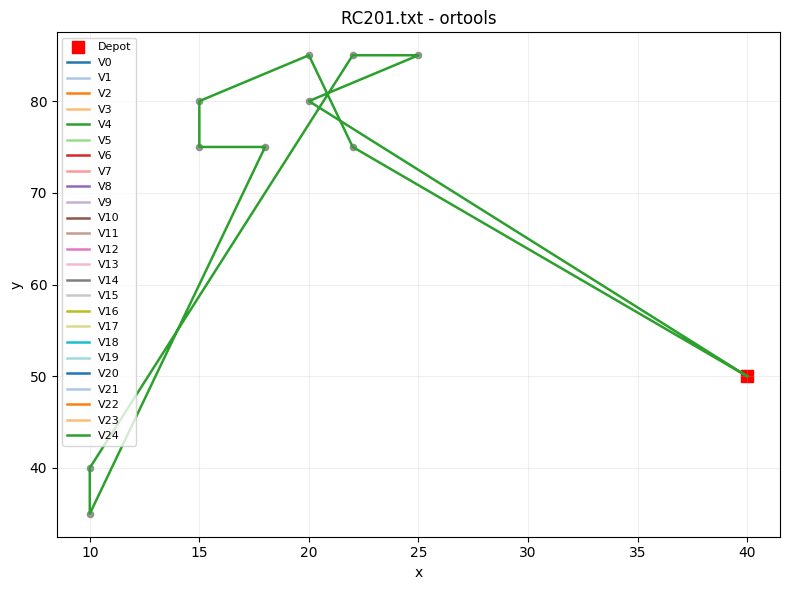

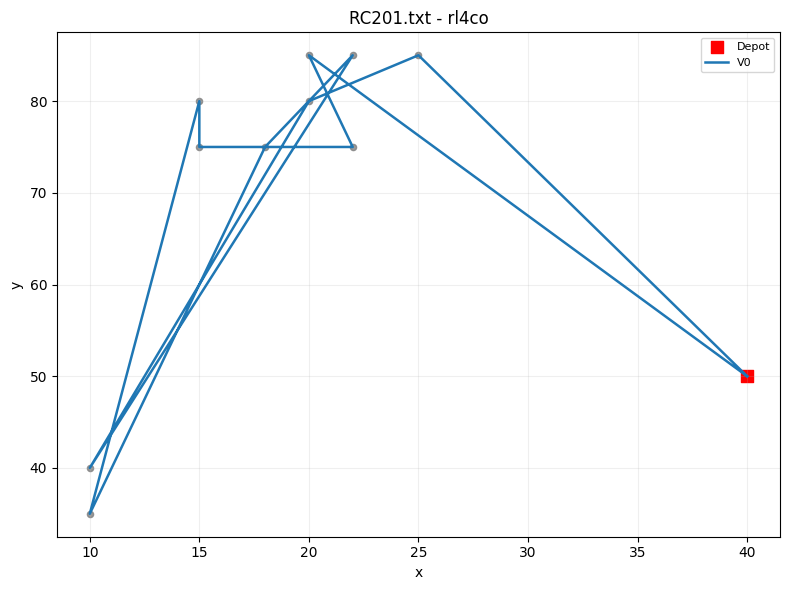

In [ ]:
from dvrptw_bench.viz.route_plot import plot_routes
plot_routes(instances[0], or_solutions[0])
plot_routes(instances[0], rl_solutions[0]) 

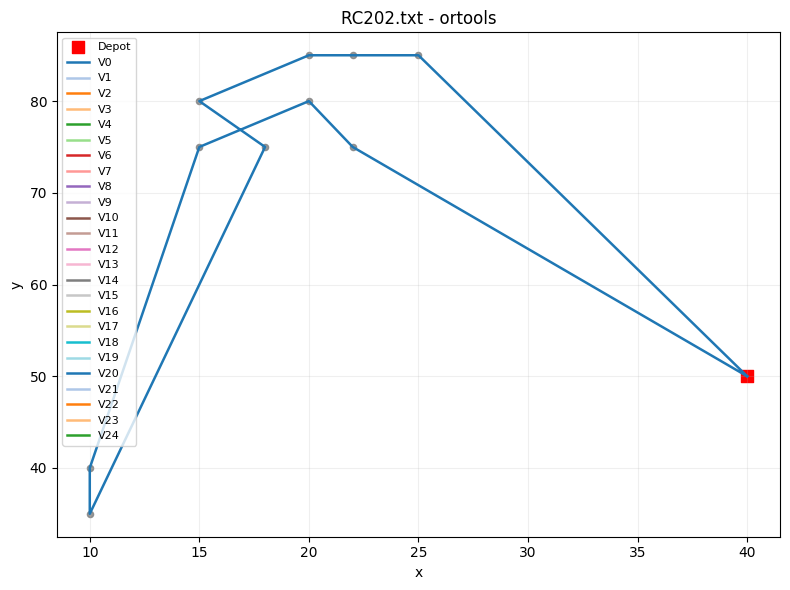

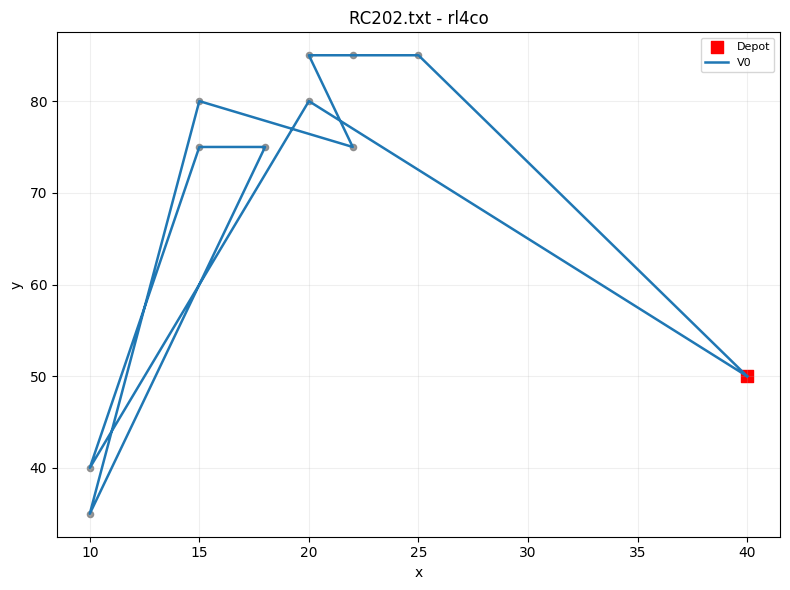

In [ ]:

plot_routes(instances[1], or_solutions[1])
plot_routes(instances[1], rl_solutions[1]) 

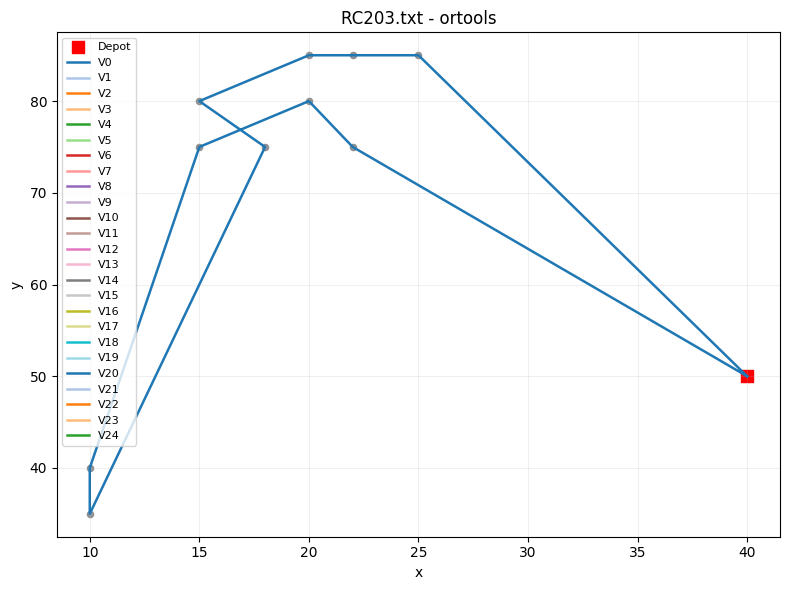

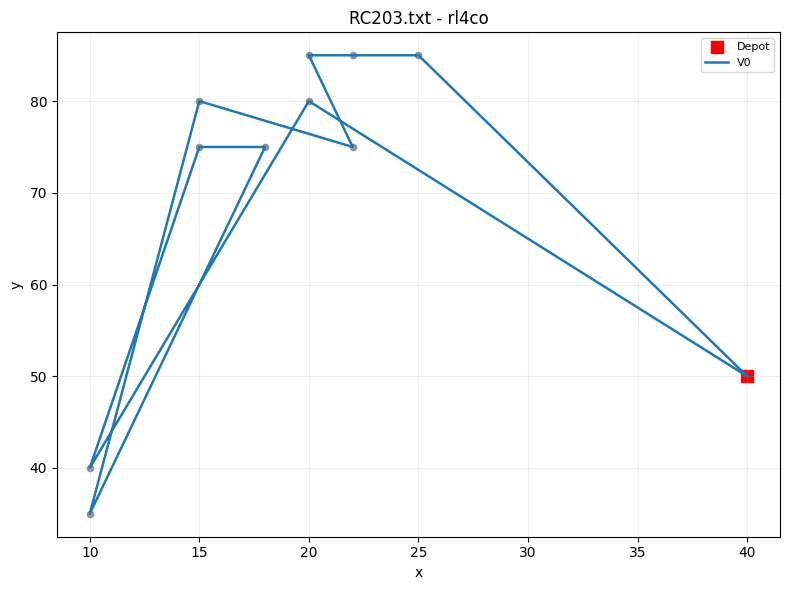

In [ ]:

plot_routes(instances[2], or_solutions[2])
plot_routes(instances[2], rl_solutions[2]) 

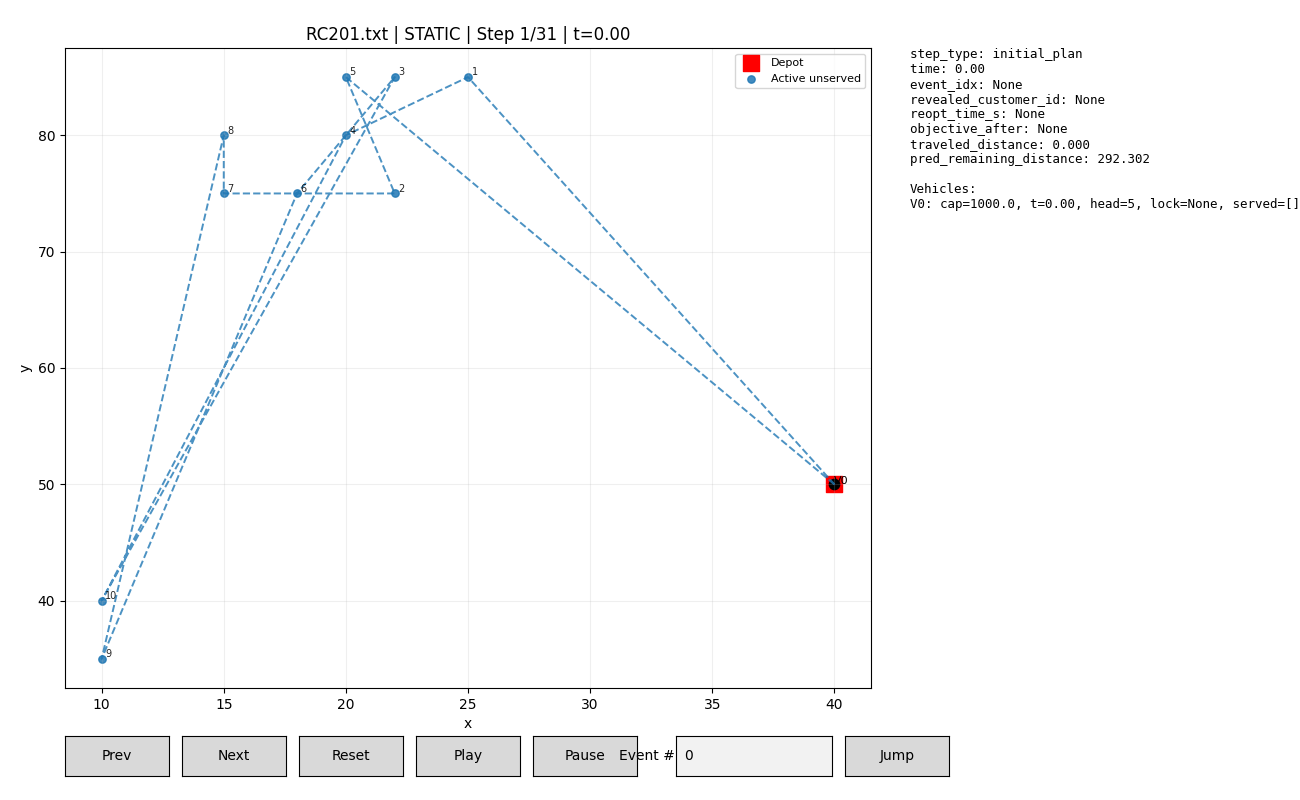

In [ ]:
%matplotlib widget
from dvrptw_bench.viz.inspector import inspect_static
# inspect rl
inspect_static(instances[0], rl_solutions[0])